In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from estimation_forecast_functions import DataCleaner_HKD
import holidays
from simple_strat_funcs import Clean_Implied_Vols_HKD_with_smile
from scipy.stats import norm
from hedging_strategy_class_NEW_KURT_SKEW_vega_VAR import Compare_Trading_Strategies
import seaborn as sns

/Users/alexvillamartin/Documents/MSc Diss/Code/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Global params

In [4]:
train_size = 0.7
test_size = 1 - train_size

TICKER = "USDUKD"

# always use same amount of money in USD to start and convert where necessary
IC_USD = 1_000_000 # initial capital in USD
current_rate = 7.85
IC_HKD = IC_USD * current_rate
NOTIONAL_USD = 1_000_000 # this is used in strategy as our notional to ensure trade positions are in domestic currency

MAX_DELTA_DIFF = 500 # this param doesnt change much as our delta positions are usually much larger
SIGNAL_LB = 0.01
SIGNAL_UB = 0.99
TRANSACTION_COST_BOOL = True
TRANSACTION_COSTS_SPOT = 0.0002 / 2 # for half a leg ie selling/buying once not to enter and exit the trade
TRANSACTION_COSTS_OPTION = 0.0005 / 2 # [change to vol spreads later] for half a leg again, both in decimals

HYPERPARAM_SORT = 'sharpe_ratio' # can be 'sharpe_ratio', 'cagr', 'max_drawdown', 'total_return'
GARCH_1_2_INDICATOR = False

k_bar_MSM = 8
b_MSM = 2.0
gamma_kbar_MSM = 0.5

M = 300 # figarch lags

CONVERT_USD_INDICATOR = True # convert all portfolio values and metrics to USD for fair comparison - use when USD is not domestic

long_threshs = np.array([1.02, 1.03, 1.04, 1.05, 1.06, 1.07,  1.08, 1.09, 1.10, 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.20, 1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27])
short_threshs = np.array([0.98, 0.97, 0.96, 0.95, 0.94, 0.93, 0.92,  0.91, 0.90, 0.89, 0.88, 0.87, 0.86, 0.85, 0.84, 0.83, 0.82, 0.81, 0.80, 0.79, 0.78, 0.77, 0.76, 0.75, 0.74, 0.73])
sig_multipliers = np.array([1, 3, 5, 7, 9, 11, 13, 15, 17, 20])


# Global data

In [5]:
usdhkd_5m = pd.read_parquet("USD_HKD_5M.parquet").copy()[['c']]
usdhkd_5m.rename(columns={'c': 'spot'}, inplace=True)  
cleaner_usdhkd = DataCleaner_HKD(usdhkd_5m, start_hr=2, end_hr=18, unit_test=False) 
realised_variance_usdhkd = cleaner_usdhkd.clean_data()
daily_log_returns_usdhkd = pd.read_parquet("DF_D_USDHKD.parquet")['Log_r']
start_date = pd.to_datetime(realised_variance_usdhkd.index.min())
end_date = pd.to_datetime(realised_variance_usdhkd.index.max())
spot_curr = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDHKD.parquet")
overnight_domestic_rate = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/honia_overnight.csv").set_index("date") 
overnight_domestic_rate.index = (pd.to_datetime(overnight_domestic_rate.index, format='mixed').normalize())
overnight_foreign_rate = pd.read_csv("SOFR_daily.csv").set_index("date")

# Global functions

Change holidays where needed. 

In [6]:
def align_spots(df, aligned_df, start, end):

    df = df[(df.index >= start) & (df.index <= end)]

    years = range(start.year, end.year + 1)

    first = holidays.US(years=years)
    second = holidays.HK(years=years)

    hols = pd.to_datetime(list(set(first) | set(second))).normalize()

    idx  = df.index
    mask = ~idx.isin(hols)
    new_df = df.loc[mask]

    df_aligned_dates = aligned_df.index
    common_dates = new_df.index.intersection(df_aligned_dates)
    new_df = new_df.loc[common_dates]

    return new_df

def sort_rates(r_b, r_t, overn_r, aligned_df, overn_for_r):

    r_b.index = pd.to_datetime(r_b.index)
    valid_mask = ~( 
                   r_t.index.isna())
    r_t_clean = r_t[valid_mask]
    r_t_clean.index = pd.to_datetime(r_t_clean.index, format='%Y-%m-%d')
    
    valid_mask2 = ~(
                   overn_r.index.isna())
    overn_r_clean = overn_r[valid_mask2]
    overn_r_clean.index = pd.to_datetime(overn_r_clean.index, format='%Y-%m-%d')

    valid_mask3 = ~(
                   overn_for_r.index.isna())
    overn_for_r_clean = overn_for_r[valid_mask3]
    overn_for_r_clean.index = pd.to_datetime(overn_for_r_clean.index, format='mixed').normalize()    

    r_b = r_b.reindex(aligned_df.index)
    r_t_clean = r_t_clean.reindex(aligned_df.index)
    overn_r_clean = overn_r_clean.reindex(aligned_df.index)
    overn_for_r_clean = overn_for_r_clean.reindex(aligned_df.index)

    r_b = r_b.ffill()
    r_t_clean = r_t_clean.ffill()
    overn_r_clean = overn_r_clean.ffill()
    overn_for_r_clean = overn_for_r_clean.ffill()

    # convert into decimals and continously compunded versions for BSE
    r_b = pd.to_numeric(r_b['rate_pct'], errors='coerce')
    r_t_clean = pd.to_numeric(r_t_clean['rate_pct'], errors='coerce')
    overn_r_clean = pd.to_numeric(overn_r_clean['rate'], errors='coerce')
    r_b = r_b / 100
    r_t_clean = r_t_clean / 100
    overn_r_clean = overn_r_clean / 100 # not continously compounded
    overn_r_clean *= 1/365 # daily

    overn_for_r_clean = pd.to_numeric(overn_for_r_clean['value'], errors='coerce')
    overn_for_r_clean = overn_for_r_clean / 100 # not continously compounded
    overn_for_r_clean *= 1/365 # daily

    r_b = np.log(1 + r_b)
    r_t_clean = np.log(1 + r_t_clean)

    return r_b, r_t_clean, overn_r_clean, overn_for_r_clean

# H=30, T=1Mo

In [7]:
OPTION_MATURITY_1 = 1 / 12
H_1 = 30 

implied_vol_data_1 = pd.read_excel('/Users/alexvillamartin/Documents/MSc Diss/Code/USDHKD_1MO_ATM_D.xlsx')
vol_smile_data_1 = pd.read_csv("usdhkd_vol_smile_1mo_extra.csv").set_index("CalculationDate")
Data_clean_1 = Clean_Implied_Vols_HKD_with_smile(data=implied_vol_data_1, 
                                start_date=start_date, 
                                end_date=end_date, 
                                align_df1=realised_variance_usdhkd, 
                                align_df2=daily_log_returns_usdhkd, 
                                smile_df=vol_smile_data_1)
implied_vol_data_1, realised_variance_1, daily_log_returns_1, vol_smile_data_1 = Data_clean_1.get_clean_data()

N_1 = len(daily_log_returns_1)
test_align_1 = daily_log_returns_1.iloc[N_1//2:-H_1]
spot_curr_test_1 = align_spots(spot_curr, test_align_1, start_date, end_date)

r_b_1 = pd.read_csv("SOFR_1mo_compounded.csv").set_index("date")
r_t_1 = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/honia_1mo_compounded.csv").set_index("date")[['rate_pct']]

r_b_test_1, r_t_test_1, overn_dom_r_test_1, overn_for_r_test_1= sort_rates(r_b_1, r_t_1, overnight_domestic_rate, test_align_1, overnight_foreign_rate) 
r_b_test_1.ffill(inplace=True)

Estimated parameters: m0=1.577052e+00, sigma_bar=2.756652e-02
Final log-likelihood: 2.767892e+03
Estimated parameters: m0=1.579971e+00, sigma_bar=4.025620e-02
Final log-likelihood: 4.653722e+03


[I 2025-09-03 22:33:48,530] A new study created in memory with name: no-name-03052545-c671-46eb-a18a-62af9e1743b4
[I 2025-09-03 22:33:49,355] Trial 0 finished with value: 1.0864746584757934 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.0864746584757934.
[I 2025-09-03 22:33:50,272] Trial 1 finished with value: 0.7999839519804908 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 1.0864746584757934.
[I 2025-09-03 22:33:51,093] Trial 2 finished with value: 0.2160683480374708 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 1.0864746584757934.
[I 2025-09-03 22:33:51,833] Trial 3 finished with value: 1.0620398540246425 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 0 with value: 1.0864746584757934.
[I 2025-09-03 22:33:52,7

Estimated parameters: omega=4.771622502566933e-05, alpha=0.1510, beta=0.8257
Estimated parameters: omega=3.098029696817893e-05, alpha=0.1525, beta=0.8335


[I 2025-09-03 22:43:58,137] A new study created in memory with name: no-name-b0004cd5-829c-4007-8967-baabd6fd6bde
[I 2025-09-03 22:43:58,951] Trial 0 finished with value: 1.4519323803661852 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.4519323803661852.
[I 2025-09-03 22:43:59,825] Trial 1 finished with value: 1.5607583206173095 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 1.5607583206173095.
[I 2025-09-03 22:44:00,699] Trial 2 finished with value: 1.3148956824343552 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 1 with value: 1.5607583206173095.
[I 2025-09-03 22:44:01,441] Trial 3 finished with value: 1.4683854563233347 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 1 with value: 1.5607583206173095.
[I 2025-09-03 22:44:02,3

Estimated parameters: omega=0.00019256353267821114, d=0.6022, beta=0.0332
Final log-likelihood = 7167.1497
Estimated parameters: omega=0.00013050018772986125, d=0.5578, beta=0.0883
Final log-likelihood = 12160.6514


[I 2025-09-03 22:54:10,119] A new study created in memory with name: no-name-23a68931-8ae8-445f-9945-3da38eb9e1ad
[I 2025-09-03 22:54:10,916] Trial 0 finished with value: 1.02198779091419 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.02198779091419.
[I 2025-09-03 22:54:11,765] Trial 1 finished with value: 0.6660655332293515 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 1.02198779091419.
[I 2025-09-03 22:54:12,594] Trial 2 finished with value: 0.713700163016892 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 1.02198779091419.
[I 2025-09-03 22:54:13,371] Trial 3 finished with value: 0.870678856475303 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 0 with value: 1.02198779091419.
[I 2025-09-03 22:54:14,221] Trial 4 

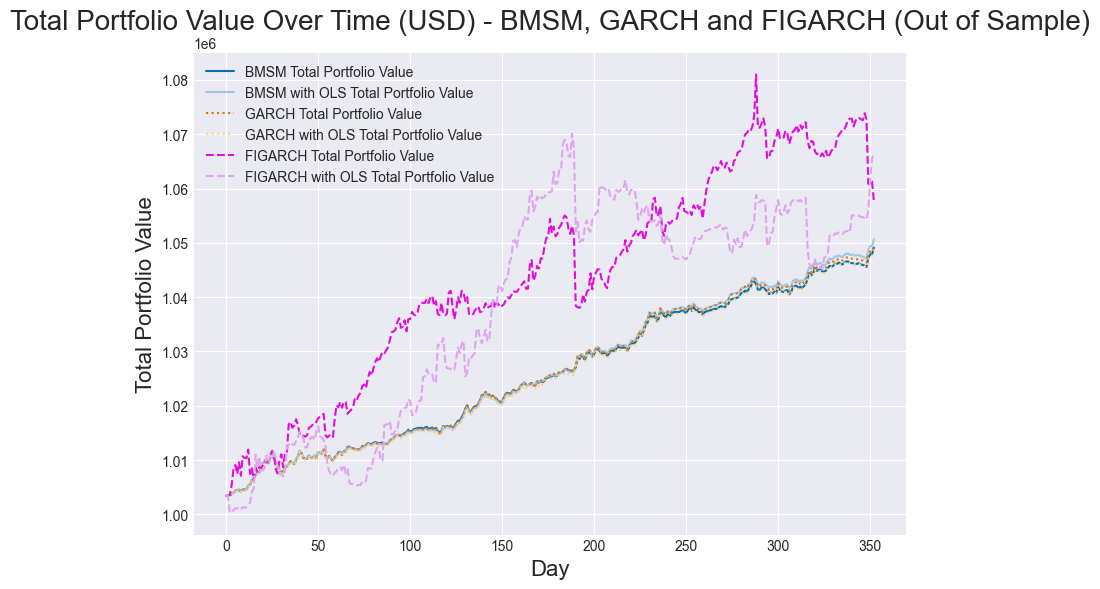

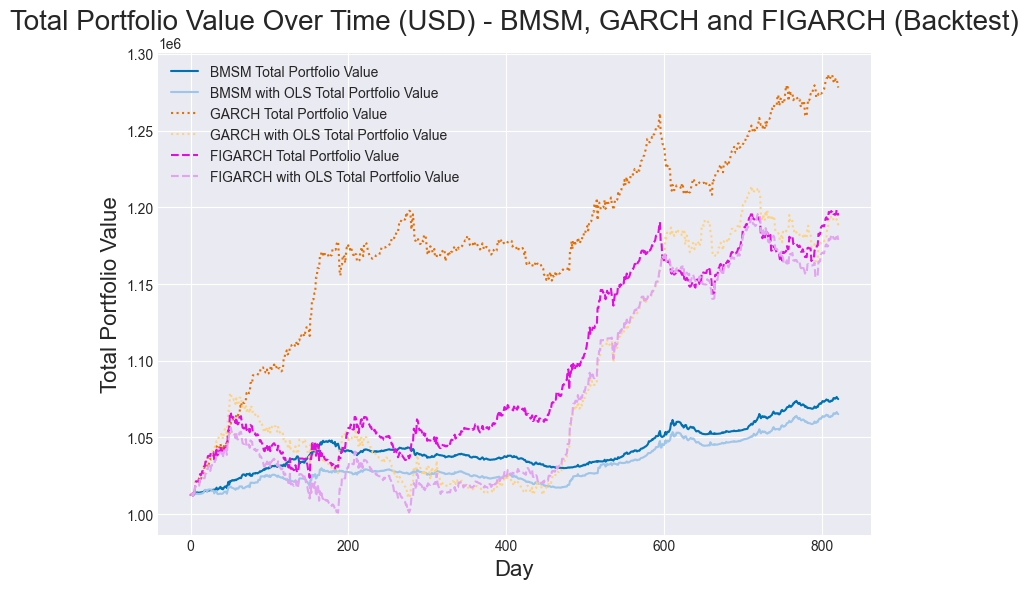

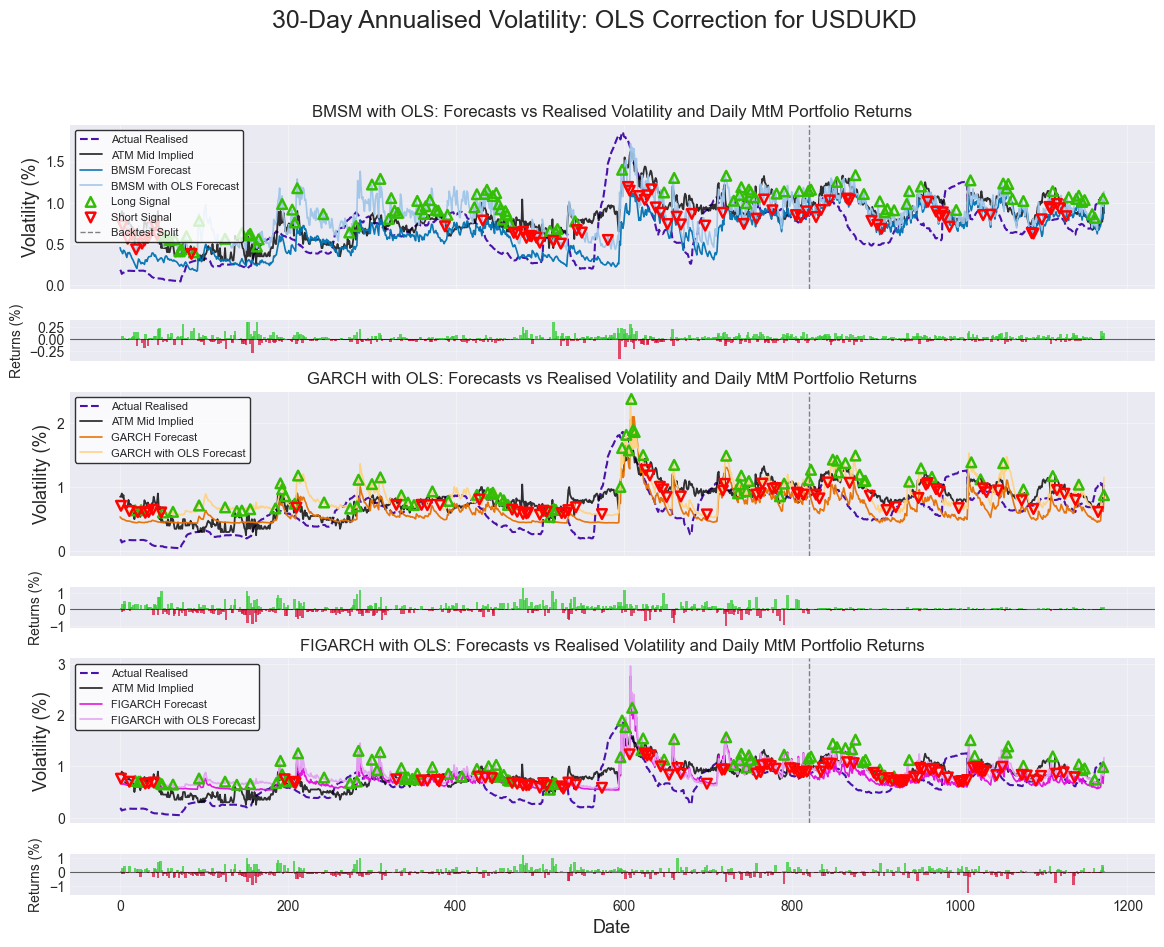

In [8]:
strategy_1 = Compare_Trading_Strategies(
    return_series=daily_log_returns_1, 
    realised_variance_series=realised_variance_1,
    atm_implied_vol_data=implied_vol_data_1,
    vol_smile_data=vol_smile_data_1,
    train_size=train_size,
    ticker=TICKER,
    initial_capital_domestic=IC_HKD,
    notional_base=NOTIONAL_USD,
    maximum_delta_difference=MAX_DELTA_DIFF,
    signal_lb=SIGNAL_LB,
    signal_ub=SIGNAL_UB,
    transaction_cost_indicator=TRANSACTION_COST_BOOL,
    transaction_costs_spot=TRANSACTION_COSTS_SPOT,
    transaction_costs_option=TRANSACTION_COSTS_OPTION,
    option_maturity=OPTION_MATURITY_1,
    forecast_horizon=H_1,
    spot_series=spot_curr_test_1,
    overnight_domestic_rate=overn_dom_r_test_1,
    overnight_foreign_rate=overn_for_r_test_1,
    domestic_rate=r_t_test_1,
    foreign_rate=r_b_test_1, 
    plots = False, 
    verbose=False, 
    sort_hyperparams_by=HYPERPARAM_SORT, 
    garch_1_2_indicator=GARCH_1_2_INDICATOR, 
    kbar=k_bar_MSM,
    b=b_MSM,
    gamma_kbar=gamma_kbar_MSM,
    convert_USD=CONVERT_USD_INDICATOR, 
    M = M, 
    long_thresholds=long_threshs,
    short_thresholds=short_threshs,
    sig_multipliers=sig_multipliers)

df_1 = strategy_1.compare_strategies(verbose = False)

In [9]:
df_1

,long_threshold,short_threshold,signal_multiplier,sharpe_ratio (USD),max_drawdown (USD),calmar_ratio (USD),cagr (USD),Precision (all),Precision (active),Win/loss ratio (all),Win/loss ratio (active),Avg win (all),Avg win (active),Avg loss (all),Avg loss (active),Non-active share,Total trades
BMSM Backtest,1.02,0.86,20.00,1.13,-1.72,0.67,1.85%,0.55,0.56,1.01,1.02,0.04%,0.05%,-0.04%,-0.05%,0.12,75.00
BMSM Out of Sample,1.02,0.86,20.00,0.78,-0.33,1.66,3.23%,0.49,0.54,1.16,1.13,0.04%,0.04%,-0.03%,-0.03%,0.31,69.00
BMSM with OLS Backtest,1.27,0.73,20.00,0.86,-1.23,0.72,1.57%,0.49,0.54,1.21,1.23,0.04%,0.05%,-0.04%,-0.04%,0.37,113.00
BMSM with OLS Out of Sample,1.27,0.73,20.00,0.92,-0.33,1.99,3.34%,0.48,0.46,1.23,0.90,0.04%,0.03%,-0.03%,-0.03%,0.79,51.00
GARCH Backtest,1.25,0.98,20.00,1.83,-4.21,1.54,7.40%,0.56,0.58,1.13,1.05,0.15%,0.17%,-0.13%,-0.17%,0.18,83.00
GARCH Out of Sample,1.25,0.98,20.00,0.82,-0.33,1.75,3.26%,0.49,0.49,1.18,1.18,0.04%,0.04%,-0.03%,-0.03%,0.05,15.00
GARCH with OLS Backtest,1.18,0.82,20.00,1.05,-6.31,0.67,5.03%,0.49,0.50,1.30,1.26,0.18%,0.23%,-0.14%,-0.18%,0.27,100.00
GARCH with OLS Out of Sample,1.18,0.82,20.00,0.75,-0.33,1.59,3.21%,0.48,0.47,1.21,1.22,0.04%,0.04%,-0.03%,-0.03%,0.40,41.00
FIGARCH Backtest,1.15,0.85,20.00,1.20,-3.99,1.10,5.20%,0.50,0.53,1.29,1.20,0.17%,0.20%,-0.13%,-0.17%,0.25,108.00
FIGARCH Out of Sample,1.15,0.85,20.00,0.41,-2.15,0.52,3.84%,0.60,0.62,0.72,0.68,0.09%,0.10%,-0.13%,-0.15%,0.10,24.00


# H=91, T=3MO

In [10]:
OPTION_MATURITY_2 = 3 / 12
H_2 = 91 

vol_smile_data_2 = pd.read_csv("usdhkd_vol_smile_3mo_extra.csv").set_index("CalculationDate")
implied_vol_data_2 = pd.DataFrame({
    'Exchange Date': vol_smile_data_2.index, 
    "Bid": vol_smile_data_2['ATM'], 
    "Ask": vol_smile_data_2['ATM'],
    "BidNet": vol_smile_data_2['ATM']})
Data_clean_2 = Clean_Implied_Vols_HKD_with_smile(data=implied_vol_data_2, 
                                start_date=start_date, 
                                end_date=end_date, 
                                align_df1=realised_variance_usdhkd, 
                                align_df2=daily_log_returns_usdhkd, 
                                smile_df=vol_smile_data_2)
implied_vol_data_2, realised_variance_2, daily_log_returns_2, vol_smile_data_2 = Data_clean_2.get_clean_data()

N_2 = len(daily_log_returns_2)
test_align_2 = daily_log_returns_2.iloc[N_2//2:-H_2]
spot_curr_test_2 = align_spots(spot_curr, test_align_2, start_date, end_date)

r_b_2 = pd.read_csv("SOFR_3mo_compounded.csv").set_index("date")
r_t_2 = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/honia_3mo_compounded.csv").set_index("date")[['rate_pct']]

r_b_test_2, r_t_test_2, overn_dom_r_test_2, overn_for_r_test_2= sort_rates(r_b_2, r_t_2, overnight_domestic_rate, test_align_2, overnight_foreign_rate) 
r_b_test_2.ffill(inplace=True)

Estimated parameters: m0=1.577052e+00, sigma_bar=2.756652e-02
Final log-likelihood: 2.767892e+03
Estimated parameters: m0=1.585861e+00, sigma_bar=4.076489e-02
Final log-likelihood: 4.597289e+03


[I 2025-09-03 23:06:02,634] A new study created in memory with name: no-name-7149836b-7f8c-4d98-b742-79a338fa4f8f
[I 2025-09-03 23:06:03,543] Trial 0 finished with value: 0.8446771199162892 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.8446771199162892.
[I 2025-09-03 23:06:04,510] Trial 1 finished with value: 0.9699759650027698 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 0.9699759650027698.
[I 2025-09-03 23:06:05,455] Trial 2 finished with value: 0.5866482799664229 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 1 with value: 0.9699759650027698.
[I 2025-09-03 23:06:06,317] Trial 3 finished with value: 0.755112516096864 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 1 with value: 0.9699759650027698.
[I 2025-09-03 23:06:07,22

Estimated parameters: omega=4.771622502566933e-05, alpha=0.1510, beta=0.8257
Estimated parameters: omega=7.168311789386581e-05, alpha=0.3299, beta=0.6597


[I 2025-09-03 23:16:47,035] A new study created in memory with name: no-name-83292fcb-ac24-4009-915d-d35ffef2b5fc
[I 2025-09-03 23:16:47,844] Trial 0 finished with value: 0.8951365579908519 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.8951365579908519.
[I 2025-09-03 23:16:48,712] Trial 1 finished with value: 0.5572720414903797 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 0.8951365579908519.
[I 2025-09-03 23:16:49,622] Trial 2 finished with value: 0.8603290538661449 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 0.8951365579908519.
[I 2025-09-03 23:16:50,368] Trial 3 finished with value: 0.11231871888362945 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 0 with value: 0.8951365579908519.
[I 2025-09-03 23:16:51,

Estimated parameters: omega=0.00019256353267821114, d=0.6022, beta=0.0332
Final log-likelihood = 7167.1497
Estimated parameters: omega=0.00013120867716117588, d=0.5615, beta=0.0853
Final log-likelihood = 11967.2892


[I 2025-09-03 23:27:16,829] A new study created in memory with name: no-name-1b97a2d3-8d9f-4fcc-a7bf-ffc2a6d37bc5
[I 2025-09-03 23:27:17,602] Trial 0 finished with value: 0.3268692380436823 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.3268692380436823.
[I 2025-09-03 23:27:18,615] Trial 1 finished with value: 1.2571082329529473 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 1 with value: 1.2571082329529473.
[I 2025-09-03 23:27:19,772] Trial 2 finished with value: 1.1336124561652996 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 1 with value: 1.2571082329529473.
[I 2025-09-03 23:27:20,525] Trial 3 finished with value: 0.40720562197219823 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 1 with value: 1.2571082329529473.
[I 2025-09-03 23:27:21,

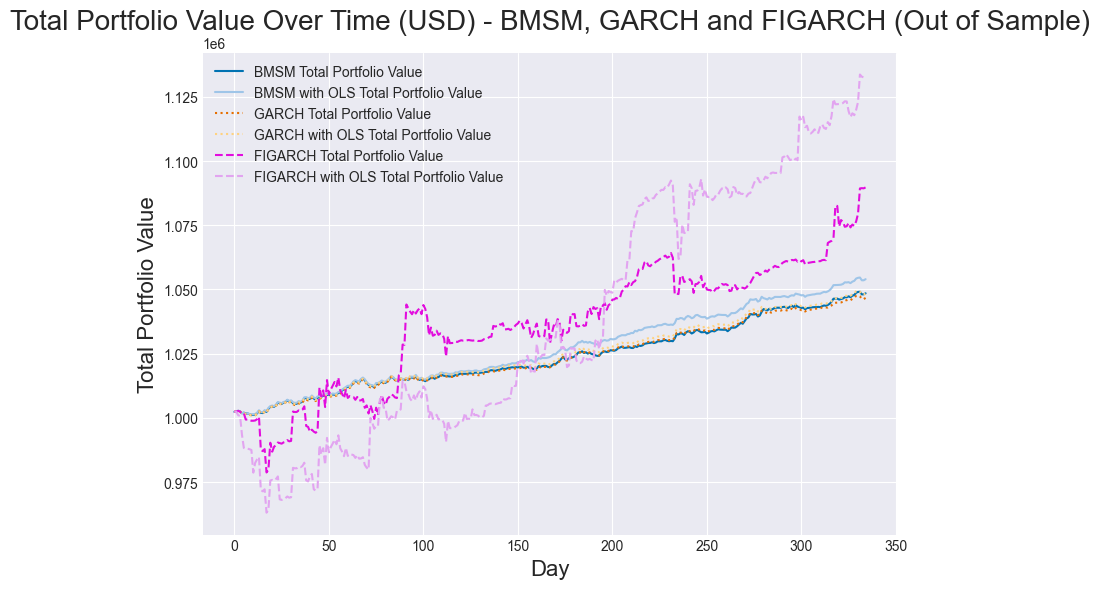

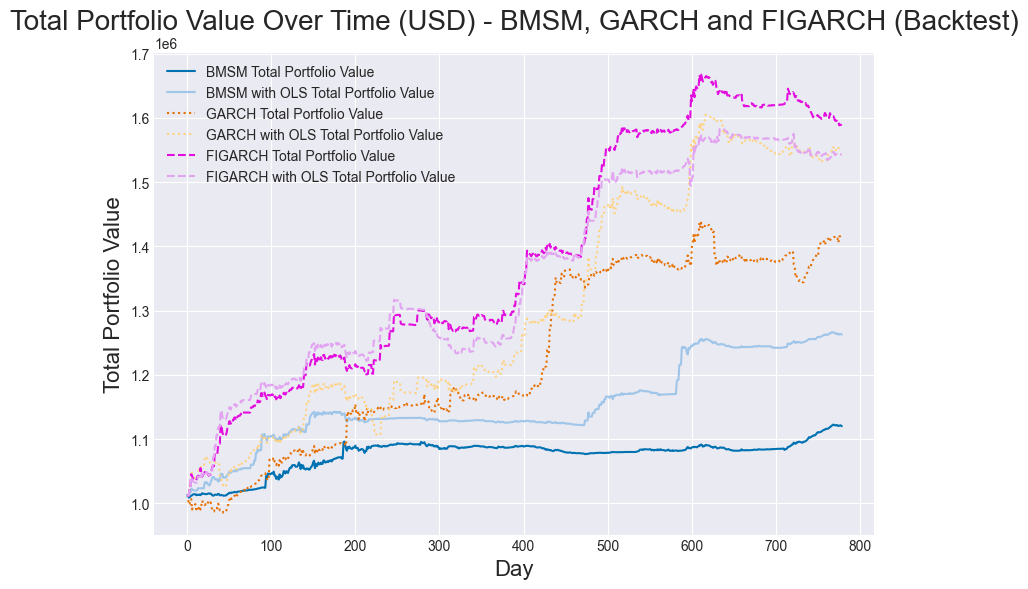

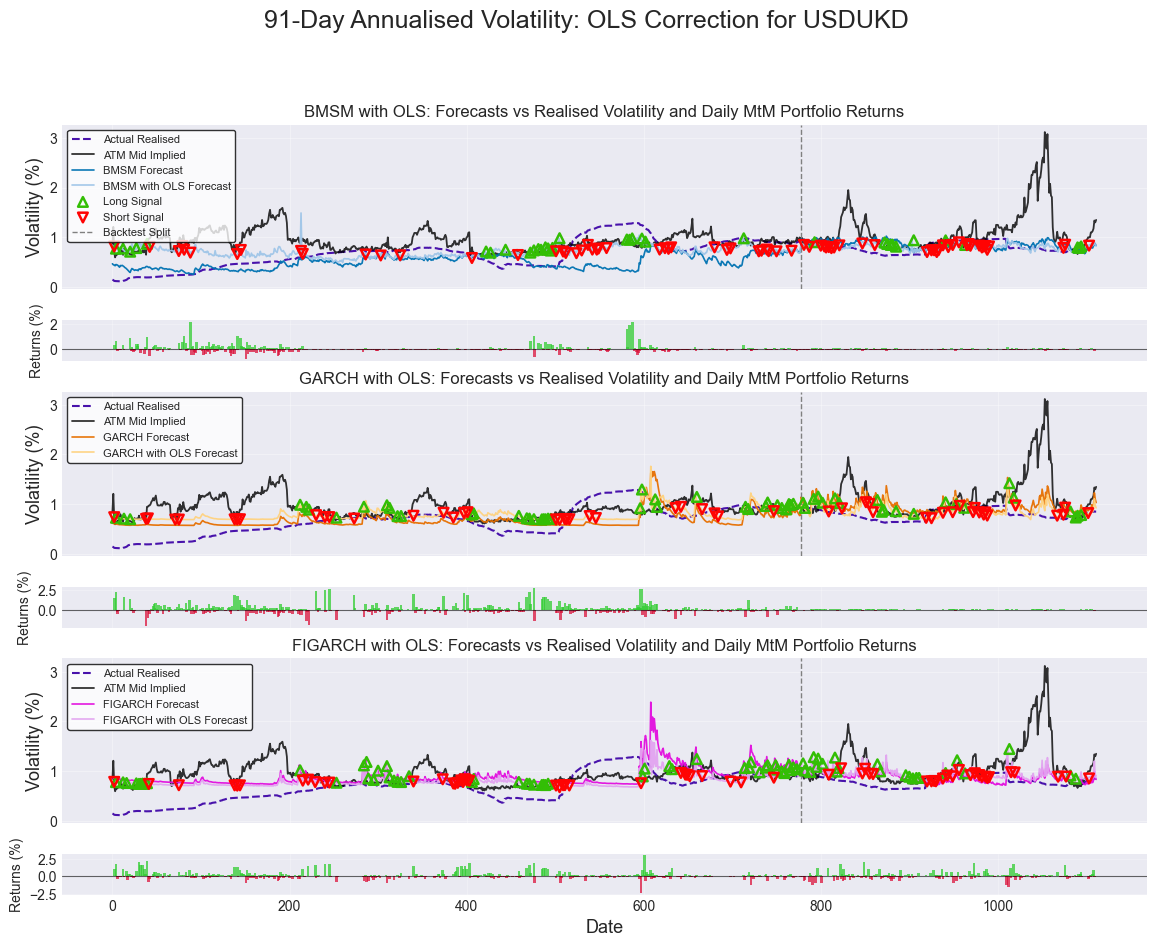

In [11]:
strategy_2 = Compare_Trading_Strategies(
    return_series=daily_log_returns_2, 
    realised_variance_series=realised_variance_2,
    atm_implied_vol_data=implied_vol_data_2,
    vol_smile_data=vol_smile_data_2,
    train_size=train_size,
    ticker=TICKER,
    initial_capital_domestic=IC_HKD,
    notional_base=NOTIONAL_USD,
    maximum_delta_difference=MAX_DELTA_DIFF,
    signal_lb=SIGNAL_LB,
    signal_ub=SIGNAL_UB,
    transaction_cost_indicator=TRANSACTION_COST_BOOL,
    transaction_costs_spot=TRANSACTION_COSTS_SPOT,
    transaction_costs_option=TRANSACTION_COSTS_OPTION,
    option_maturity=OPTION_MATURITY_2,
    forecast_horizon=H_2,
    spot_series=spot_curr_test_2,
    overnight_domestic_rate=overn_dom_r_test_2,
    overnight_foreign_rate=overn_for_r_test_2,
    domestic_rate=r_t_test_2,
    foreign_rate=r_b_test_2, 
    plots = False, 
    verbose=False, 
    sort_hyperparams_by=HYPERPARAM_SORT, 
    garch_1_2_indicator=GARCH_1_2_INDICATOR, 
    kbar=k_bar_MSM,
    b=b_MSM,
    gamma_kbar=gamma_kbar_MSM,
    convert_USD=CONVERT_USD_INDICATOR, 
    M = M, 
    long_thresholds=long_threshs,
    short_thresholds=short_threshs,
    sig_multipliers=sig_multipliers)

df_2 = strategy_2.compare_strategies(verbose = False)

In [12]:
df_2

,long_threshold,short_threshold,signal_multiplier,sharpe_ratio (USD),max_drawdown (USD),calmar_ratio (USD),cagr (USD),Precision (all),Precision (active),Win/loss ratio (all),Win/loss ratio (active),Avg win (all),Avg win (active),Avg loss (all),Avg loss (active),Non-active share,Total trades
BMSM Backtest,1.02,0.96,20.00,1.01,-1.79,1.52,3.33%,0.54,0.54,1.13,1.12,0.08%,0.08%,-0.07%,-0.07%,0.02,16.00
BMSM Out of Sample,1.02,0.96,20.00,0.92,-0.33,2.00,3.44%,0.49,0.49,1.20,1.21,0.04%,0.04%,-0.03%,-0.03%,0.12,31.00
BMSM with OLS Backtest,1.13,0.75,20.00,1.89,-1.85,3.57,7.41%,0.51,0.53,1.72,1.64,0.12%,0.15%,-0.07%,-0.09%,0.27,61.00
BMSM with OLS Out of Sample,1.13,0.75,20.00,1.51,-0.33,3.19,3.85%,0.51,0.53,1.24,1.25,0.04%,0.04%,-0.03%,-0.03%,0.39,44.00
GARCH Backtest,1.05,0.90,20.00,1.48,-6.47,1.57,11.33%,0.57,0.58,1.08,1.05,0.24%,0.25%,-0.22%,-0.24%,0.07,37.00
GARCH Out of Sample,1.05,0.90,20.00,0.73,-0.32,1.65,3.31%,0.49,0.50,1.17,1.13,0.04%,0.04%,-0.03%,-0.03%,0.19,40.00
GARCH with OLS Backtest,1.05,0.76,20.00,1.81,-6.78,1.96,14.85%,0.50,0.52,1.57,1.47,0.29%,0.38%,-0.19%,-0.26%,0.27,68.00
GARCH with OLS Out of Sample,1.05,0.76,20.00,0.91,-0.31,2.15,3.44%,0.50,0.53,1.16,1.05,0.04%,0.04%,-0.03%,-0.03%,0.34,42.00
FIGARCH Backtest,1.24,0.90,20.00,2.19,-4.74,2.96,15.69%,0.51,0.53,1.66,1.56,0.26%,0.33%,-0.16%,-0.21%,0.24,63.00
FIGARCH Out of Sample,1.24,0.90,20.00,0.74,-2.39,1.49,6.49%,0.53,0.55,1.03,0.99,0.17%,0.21%,-0.16%,-0.22%,0.27,21.00


# H=182, T=6MO

In [13]:
OPTION_MATURITY_3 = 6 / 12
H_3 = 182

vol_smile_data_3 = pd.read_csv("usdhkd_vol_smile_6mo_extra.csv").set_index("CalculationDate")
implied_vol_data_3 = pd.DataFrame({
    'Exchange Date': vol_smile_data_3.index, 
    "Bid": vol_smile_data_3['ATM'], 
    "Ask": vol_smile_data_3['ATM'],
    "BidNet": vol_smile_data_3['ATM']})
Data_clean_3 = Clean_Implied_Vols_HKD_with_smile(data=implied_vol_data_3, 
                                start_date=start_date, 
                                end_date=end_date, 
                                align_df1=realised_variance_usdhkd, 
                                align_df2=daily_log_returns_usdhkd, 
                                smile_df=vol_smile_data_3)
implied_vol_data_3, realised_variance_3, daily_log_returns_3, vol_smile_data_3 = Data_clean_3.get_clean_data()

N_3 = len(daily_log_returns_3)
test_align_3 = daily_log_returns_3.iloc[N_3//2:-H_3]
spot_curr_test_3 = align_spots(spot_curr, test_align_3, start_date, end_date)

r_b_3 = pd.read_csv("SOFR_6mo_compounded.csv").set_index("date")
r_t_3 = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/honia_6mo_compounded.csv").set_index("date")[['rate_pct']]

r_b_test_3, r_t_test_3, overn_dom_r_test_3, overn_for_r_test_3= sort_rates(r_b_3, r_t_3, overnight_domestic_rate, test_align_3, overnight_foreign_rate) 
r_b_test_3.ffill(inplace=True)

Estimated parameters: m0=1.577052e+00, sigma_bar=2.756652e-02
Final log-likelihood: 2.767892e+03
Estimated parameters: m0=1.593911e+00, sigma_bar=4.063711e-02
Final log-likelihood: 4.521357e+03


[I 2025-09-03 23:38:56,607] A new study created in memory with name: no-name-107e1e29-666a-43dc-a85b-399984bf72f3
[I 2025-09-03 23:38:57,469] Trial 0 finished with value: 0.5798408454780568 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.5798408454780568.
[I 2025-09-03 23:38:58,371] Trial 1 finished with value: 0.5650382676707207 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 0.5798408454780568.
[I 2025-09-03 23:38:59,192] Trial 2 finished with value: 0.43117708542365735 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 0.5798408454780568.
[I 2025-09-03 23:39:00,069] Trial 3 finished with value: 0.5798408454780568 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 0 with value: 0.5798408454780568.
[I 2025-09-03 23:39:00,

Estimated parameters: omega=4.771622502566933e-05, alpha=0.1510, beta=0.8257
Estimated parameters: omega=7.685684282269831e-05, alpha=0.3487, beta=0.6404


[I 2025-09-03 23:49:49,458] A new study created in memory with name: no-name-27a005dc-f0a9-4b20-af73-7368d4d645bd
[I 2025-09-03 23:49:50,334] Trial 0 finished with value: 0.8577205739230299 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.8577205739230299.
[I 2025-09-03 23:49:51,335] Trial 1 finished with value: 0.7557769247954567 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 0.8577205739230299.
[I 2025-09-03 23:49:52,199] Trial 2 finished with value: 0.6689037419728823 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 0.8577205739230299.
[I 2025-09-03 23:49:53,006] Trial 3 finished with value: -0.30532931820099246 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 0 with value: 0.8577205739230299.
[I 2025-09-03 23:49:53

Estimated parameters: omega=0.00019256353267821114, d=0.6022, beta=0.0332
Final log-likelihood = 7167.1497
Estimated parameters: omega=0.00013578046090827948, d=0.5733, beta=0.0746
Final log-likelihood = 11693.2642


[I 2025-09-03 23:59:39,034] A new study created in memory with name: no-name-a92f0288-d622-483e-8fe3-4afd437c39be
[I 2025-09-03 23:59:39,621] Trial 0 finished with value: 0.8964666584788359 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.8964666584788359.
[I 2025-09-03 23:59:40,256] Trial 1 finished with value: 0.3241393314610722 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 0.8964666584788359.
[I 2025-09-03 23:59:40,865] Trial 2 finished with value: 0.18681421339250764 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 0.8964666584788359.
[I 2025-09-03 23:59:41,351] Trial 3 finished with value: 0.599401264589282 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 0 with value: 0.8964666584788359.
[I 2025-09-03 23:59:41,9

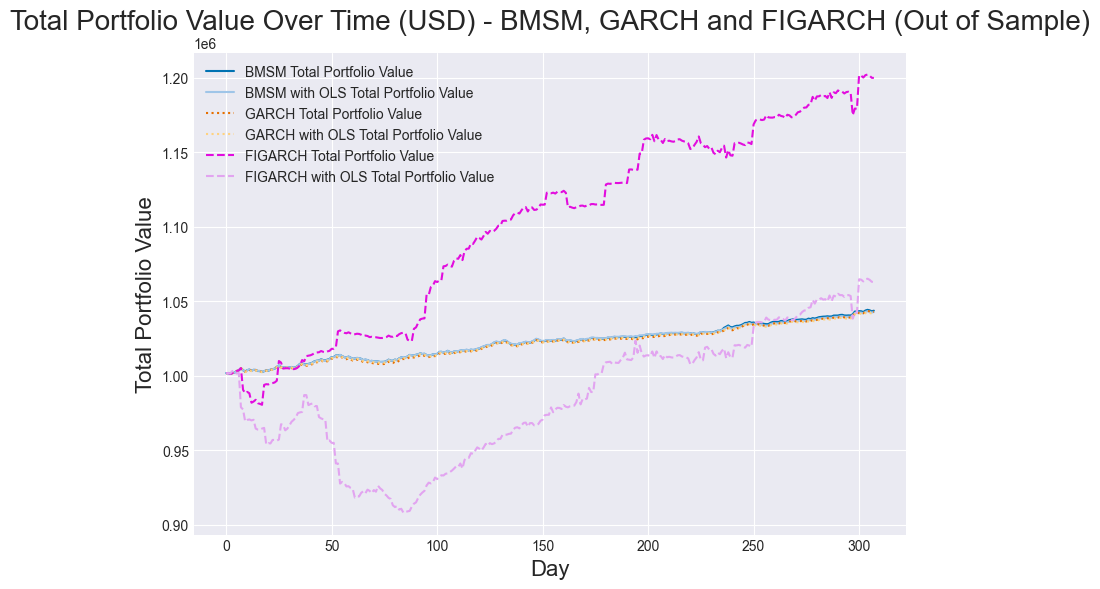

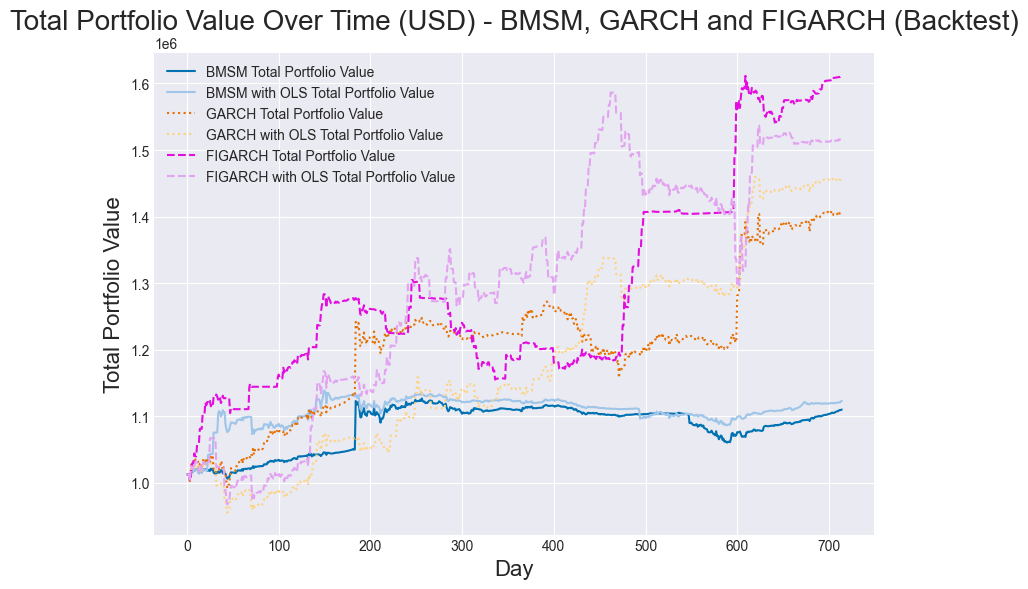

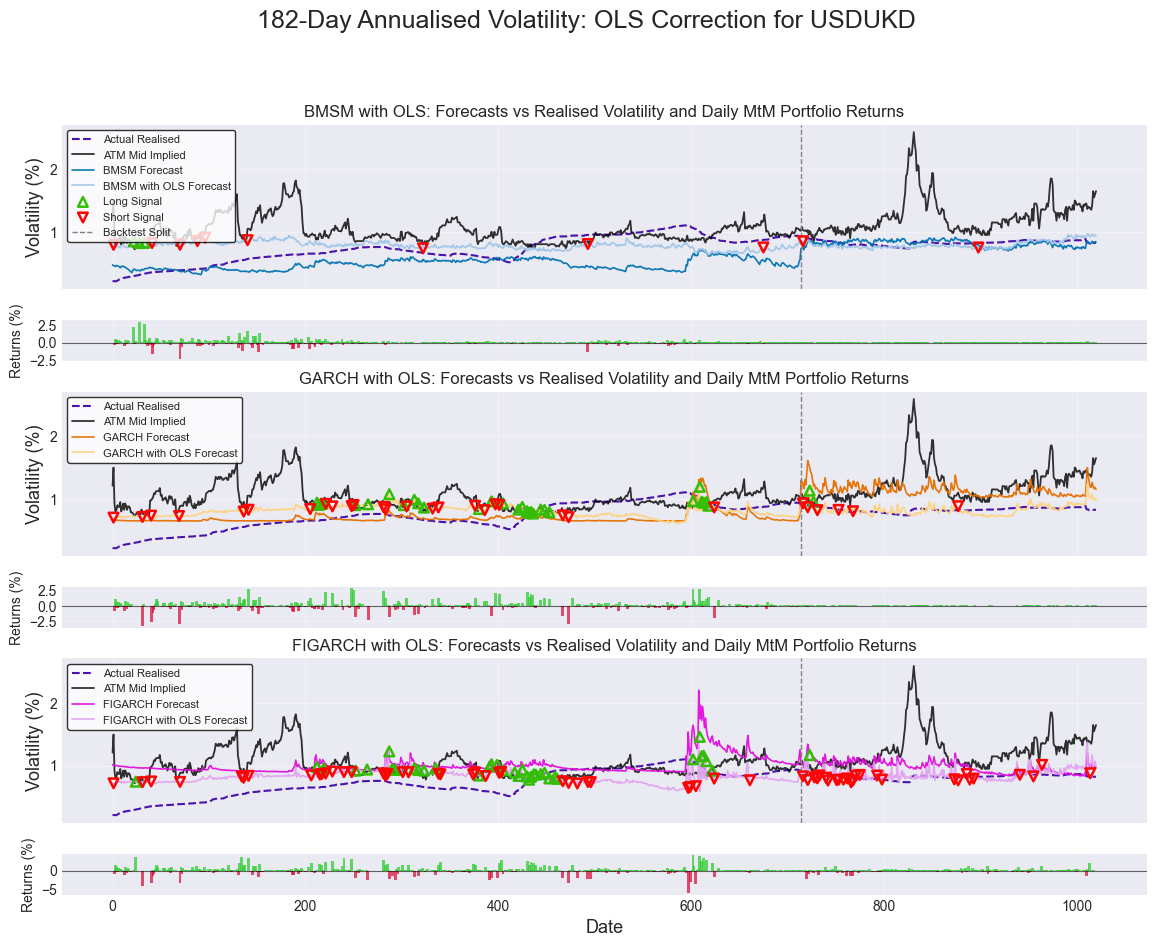

In [14]:
strategy_3 = Compare_Trading_Strategies(
    return_series=daily_log_returns_3, 
    realised_variance_series=realised_variance_3,
    atm_implied_vol_data=implied_vol_data_3,
    vol_smile_data=vol_smile_data_3,
    train_size=train_size,
    ticker=TICKER,
    initial_capital_domestic=IC_HKD,
    notional_base=NOTIONAL_USD,
    maximum_delta_difference=MAX_DELTA_DIFF,
    signal_lb=SIGNAL_LB,
    signal_ub=SIGNAL_UB,
    transaction_cost_indicator=TRANSACTION_COST_BOOL,
    transaction_costs_spot=TRANSACTION_COSTS_SPOT,
    transaction_costs_option=TRANSACTION_COSTS_OPTION,
    option_maturity=OPTION_MATURITY_3,
    forecast_horizon=H_3,
    spot_series=spot_curr_test_3,
    overnight_domestic_rate=overn_dom_r_test_3,
    overnight_foreign_rate=overn_for_r_test_3,
    domestic_rate=r_t_test_3,
    foreign_rate=r_b_test_3, 
    plots = False, 
    verbose=False, 
    sort_hyperparams_by=HYPERPARAM_SORT, 
    garch_1_2_indicator=GARCH_1_2_INDICATOR, 
    kbar=k_bar_MSM,
    b=b_MSM,
    gamma_kbar=gamma_kbar_MSM,
    convert_USD=CONVERT_USD_INDICATOR, 
    M = M, 
    long_thresholds=long_threshs,
    short_thresholds=short_threshs,
    sig_multipliers=sig_multipliers)

df_3 = strategy_3.compare_strategies(verbose = False)

In [15]:
df_3

,long_threshold,short_threshold,signal_multiplier,sharpe_ratio (USD),max_drawdown (USD),calmar_ratio (USD),cagr (USD),Precision (all),Precision (active),Win/loss ratio (all),Win/loss ratio (active),Avg win (all),Avg win (active),Avg loss (all),Avg loss (active),Non-active share,Total trades
BMSM Backtest,1.10,0.83,20.00,0.58,-5.88,0.49,3.30%,0.52,0.52,1.12,1.12,0.12%,0.12%,-0.11%,-0.11%,0.01,4.00
BMSM Out of Sample,1.10,0.83,20.00,0.74,-0.47,1.25,3.42%,0.50,0.50,1.13,1.13,0.04%,0.04%,-0.04%,-0.04%,0.02,5.00
BMSM with OLS Backtest,1.19,0.98,20.00,0.68,-4.58,0.72,3.73%,0.52,0.52,1.13,1.10,0.15%,0.15%,-0.13%,-0.14%,0.03,12.00
BMSM with OLS Out of Sample,1.19,0.98,20.00,0.65,-0.47,1.09,3.34%,0.49,0.49,1.18,1.17,0.04%,0.04%,-0.04%,-0.04%,0.01,2.00
GARCH Backtest,1.06,0.90,20.00,1.12,-9.01,1.25,12.29%,0.54,0.54,1.16,1.16,0.33%,0.33%,-0.28%,-0.29%,0.02,8.00
GARCH Out of Sample,1.06,0.90,20.00,0.65,-0.53,1.01,3.36%,0.50,0.53,1.09,1.04,0.04%,0.04%,-0.04%,-0.04%,0.14,28.00
GARCH with OLS Backtest,1.02,0.84,13.00,1.45,-7.17,1.75,13.71%,0.53,0.56,1.28,1.16,0.30%,0.35%,-0.23%,-0.31%,0.22,51.00
GARCH with OLS Out of Sample,1.02,0.84,13.00,0.58,-0.48,0.96,3.29%,0.50,0.51,1.10,1.12,0.04%,0.04%,-0.04%,-0.04%,0.03,8.00
FIGARCH Backtest,1.26,0.76,17.00,1.67,-11.48,1.40,17.85%,0.51,0.54,1.60,1.47,0.30%,0.55%,-0.19%,-0.37%,0.50,56.00
FIGARCH Out of Sample,1.26,0.76,17.00,2.50,-2.45,4.92,15.92%,0.51,0.55,1.80,1.68,0.20%,0.28%,-0.11%,-0.17%,0.40,22.00


# H=364, T=1Y

In [16]:
OPTION_MATURITY_4 = 1
H_4 = 364

vol_smile_data_4 = pd.read_csv("usdhkd_vol_smile_1y_extra.csv").set_index("CalculationDate")
implied_vol_data_4 = pd.DataFrame({
    'Exchange Date': vol_smile_data_4.index, 
    "Bid": vol_smile_data_4['ATM'], 
    "Ask": vol_smile_data_4['ATM'],
    "BidNet": vol_smile_data_4['ATM']})
Data_clean_4 = Clean_Implied_Vols_HKD_with_smile(data=implied_vol_data_4, 
                                start_date=start_date, 
                                end_date=end_date, 
                                align_df1=realised_variance_usdhkd, 
                                align_df2=daily_log_returns_usdhkd, 
                                smile_df=vol_smile_data_4)
implied_vol_data_4, realised_variance_4, daily_log_returns_4, vol_smile_data_4 = Data_clean_4.get_clean_data()

N_4 = len(daily_log_returns_4)
test_align_4 = daily_log_returns_4.iloc[N_4//2:-H_4]
spot_curr_test_4 = align_spots(spot_curr, test_align_4, start_date, end_date)

r_b_4 = pd.read_csv("SOFR_1y_compounded.csv").set_index("date")
r_t_4 = pd.read_csv("/Users/alexvillamartin/Documents/MSc Diss/Code/honia_1y_compounded.csv").set_index("date")[['rate_pct']]

r_b_test_4, r_t_test_4, overn_dom_r_test_4, overn_for_r_test_4= sort_rates(r_b_4, r_t_4, overnight_domestic_rate, test_align_4, overnight_foreign_rate) 
r_b_test_4.ffill(inplace=True)

Estimated parameters: m0=1.577052e+00, sigma_bar=2.756652e-02
Final log-likelihood: 2.767892e+03
Estimated parameters: m0=1.555780e+00, sigma_bar=2.667106e-02
Final log-likelihood: 4.303206e+03


[I 2025-09-04 00:09:04,272] A new study created in memory with name: no-name-0bb9ba5c-bdd8-4039-bc2e-27a0a576e71e
[I 2025-09-04 00:09:04,929] Trial 0 finished with value: 0.4899787799000008 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.4899787799000008.
[I 2025-09-04 00:09:05,579] Trial 1 finished with value: 0.45319342553568953 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 0.4899787799000008.
[I 2025-09-04 00:09:06,261] Trial 2 finished with value: 0.12860886940263164 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 0.4899787799000008.
[I 2025-09-04 00:09:06,915] Trial 3 finished with value: 0.4899787799000008 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 0 with value: 0.4899787799000008.
[I 2025-09-04 00:09:07

Estimated parameters: omega=4.771622502566933e-05, alpha=0.1510, beta=0.8257
Estimated parameters: omega=2.110054089742415e-05, alpha=0.1532, beta=0.8372


[I 2025-09-04 00:17:38,300] A new study created in memory with name: no-name-f3effe0c-f755-477f-96e1-3ddc6834aa3c
[I 2025-09-04 00:17:38,997] Trial 0 finished with value: 0.39746190520886654 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 0.39746190520886654.
[I 2025-09-04 00:17:39,666] Trial 1 finished with value: 0.3844462810257189 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 0.39746190520886654.
[I 2025-09-04 00:17:40,335] Trial 2 finished with value: 0.28116324896154665 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 0 with value: 0.39746190520886654.
[I 2025-09-04 00:17:41,010] Trial 3 finished with value: 0.39746190520886654 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 0 with value: 0.39746190520886654.
[I 2025-09-04 00:

Estimated parameters: omega=0.00019256353267821114, d=0.6022, beta=0.0332
Final log-likelihood = 7167.1497
Estimated parameters: omega=8.641696035472168e-05, d=0.5898, beta=0.1578
Final log-likelihood = 11123.7926


[I 2025-09-04 00:27:04,130] A new study created in memory with name: no-name-87ee37dc-1aba-4721-bb32-614c075ffe26
[I 2025-09-04 00:27:04,639] Trial 0 finished with value: 1.0964919883069633 and parameters: {'long_threshold': 1.1, 'short_threshold': 0.83, 'signal_multiplier': 20}. Best is trial 0 with value: 1.0964919883069633.
[I 2025-09-04 00:27:05,174] Trial 1 finished with value: 0.9332338623064294 and parameters: {'long_threshold': 1.15, 'short_threshold': 0.96, 'signal_multiplier': 17}. Best is trial 0 with value: 1.0964919883069633.
[I 2025-09-04 00:27:05,652] Trial 2 finished with value: 1.2623679258771443 and parameters: {'long_threshold': 1.18, 'short_threshold': 0.91, 'signal_multiplier': 7}. Best is trial 2 with value: 1.2623679258771443.
[I 2025-09-04 00:27:06,093] Trial 3 finished with value: 1.5914850241336875 and parameters: {'long_threshold': 1.14, 'short_threshold': 0.76, 'signal_multiplier': 20}. Best is trial 3 with value: 1.5914850241336875.
[I 2025-09-04 00:27:06,6

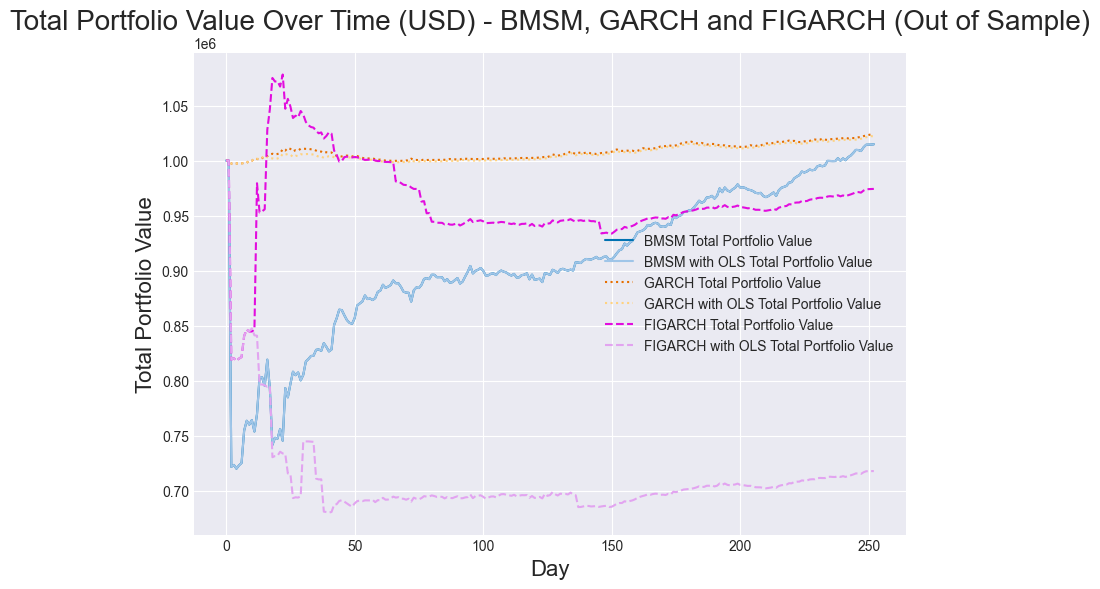

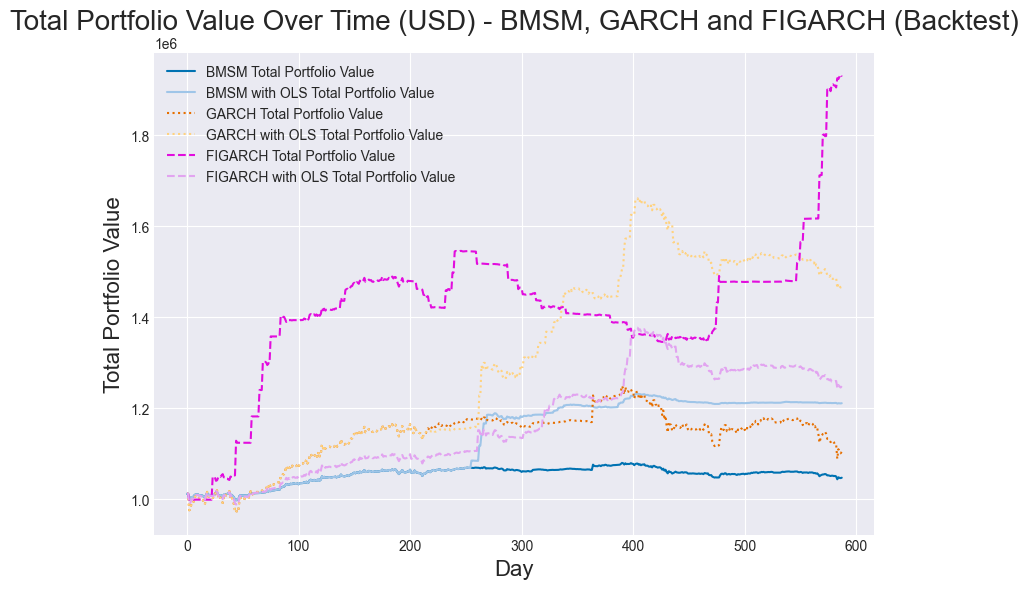

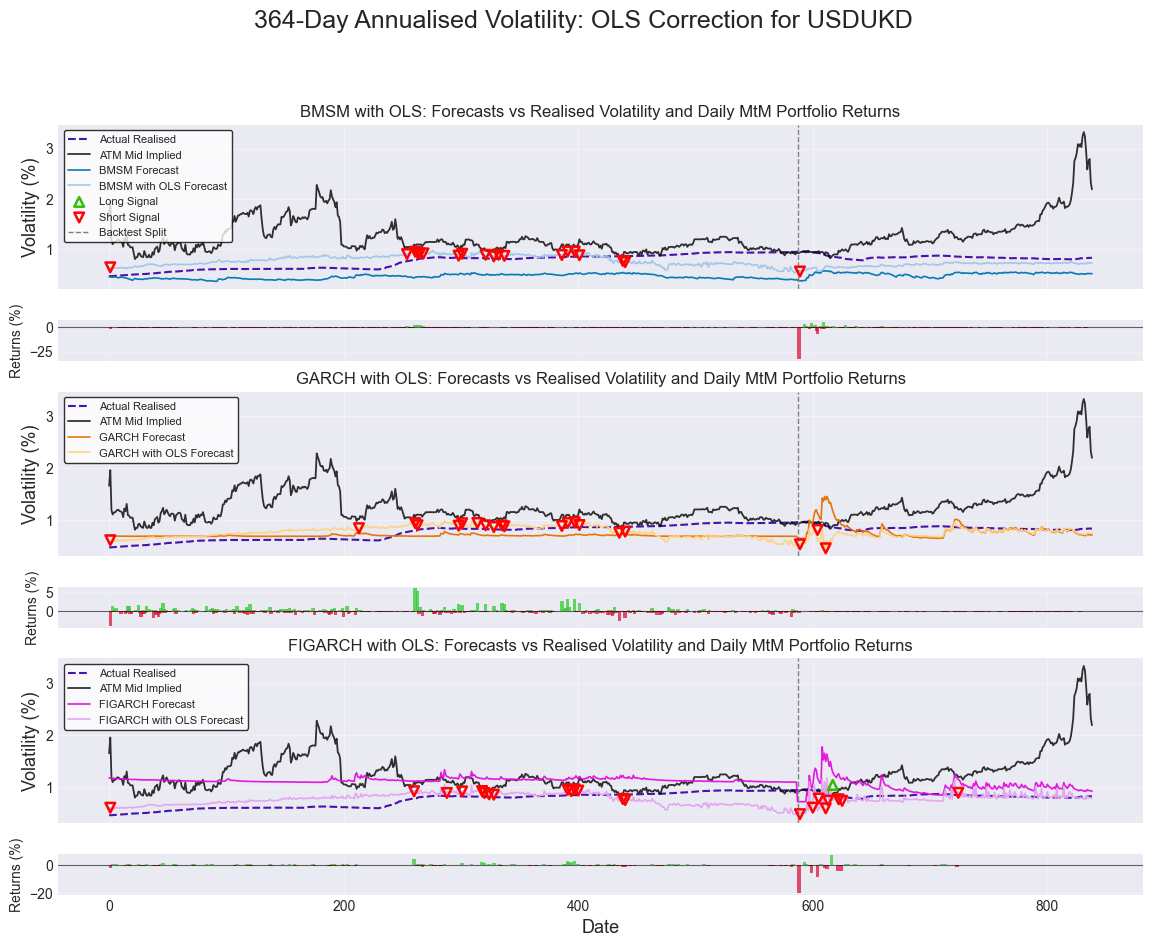

In [17]:
strategy_4 = Compare_Trading_Strategies(
    return_series=daily_log_returns_4, 
    realised_variance_series=realised_variance_4,
    atm_implied_vol_data=implied_vol_data_4,
    vol_smile_data=vol_smile_data_4,
    train_size=train_size,
    ticker=TICKER,
    initial_capital_domestic=IC_HKD,
    notional_base=NOTIONAL_USD,
    maximum_delta_difference=MAX_DELTA_DIFF,
    signal_lb=SIGNAL_LB,
    signal_ub=SIGNAL_UB,
    transaction_cost_indicator=TRANSACTION_COST_BOOL,
    transaction_costs_spot=TRANSACTION_COSTS_SPOT,
    transaction_costs_option=TRANSACTION_COSTS_OPTION,
    option_maturity=OPTION_MATURITY_4,
    forecast_horizon=H_4,
    spot_series=spot_curr_test_4,
    overnight_domestic_rate=overn_dom_r_test_4,
    overnight_foreign_rate=overn_for_r_test_4,
    domestic_rate=r_t_test_4,
    foreign_rate=r_b_test_4, 
    plots = False, 
    verbose=False, 
    sort_hyperparams_by=HYPERPARAM_SORT, 
    garch_1_2_indicator=GARCH_1_2_INDICATOR, 
    kbar=k_bar_MSM,
    b=b_MSM,
    gamma_kbar=gamma_kbar_MSM,
    convert_USD=CONVERT_USD_INDICATOR, 
    M = M, 
    long_thresholds=long_threshs,
    short_thresholds=short_threshs,
    sig_multipliers=sig_multipliers)

df_4 = strategy_4.compare_strategies(verbose = False)

In [19]:
df_4

,long_threshold,short_threshold,signal_multiplier,sharpe_ratio (USD),max_drawdown (USD),calmar_ratio (USD),cagr (USD),Precision (all),Precision (active),Win/loss ratio (all),Win/loss ratio (active),Avg win (all),Avg win (active),Avg loss (all),Avg loss (active),Non-active share,Total trades
BMSM Backtest,1.10,0.83,20.00,0.49,-3.33,0.40,1.48%,0.51,0.51,1.05,1.05,0.11%,0.11%,-0.11%,-0.11%,0.00,2.00
BMSM Out of Sample,1.10,0.83,20.00,-0.02,-27.98,-0.02,1.48%,0.61,0.61,0.64,0.63,0.44%,0.44%,-0.68%,-0.69%,0.00,1.00
BMSM with OLS Backtest,1.14,0.76,20.00,1.88,-1.82,4.16,7.99%,0.52,0.52,1.62,1.62,0.14%,0.15%,-0.08%,-0.09%,0.08,18.00
BMSM with OLS Out of Sample,1.14,0.76,20.00,-0.02,-27.98,-0.02,1.48%,0.61,0.61,0.64,0.63,0.44%,0.44%,-0.68%,-0.69%,0.00,1.00
GARCH Backtest,1.10,0.83,20.00,0.40,-12.83,0.28,3.81%,0.52,0.52,1.00,1.00,0.35%,0.35%,-0.35%,-0.35%,0.00,2.00
GARCH Out of Sample,1.10,0.83,20.00,0.21,-1.15,0.20,2.36%,0.47,0.48,1.16,1.13,0.05%,0.05%,-0.04%,-0.04%,0.04,5.00
GARCH with OLS Backtest,1.16,0.77,20.00,1.55,-11.87,1.34,17.32%,0.54,0.54,1.24,1.22,0.39%,0.42%,-0.32%,-0.34%,0.07,17.00
GARCH with OLS Out of Sample,1.16,0.77,20.00,0.07,-0.76,0.09,2.20%,0.49,0.49,1.06,1.08,0.05%,0.05%,-0.04%,-0.04%,0.01,3.00
FIGARCH Backtest,1.24,0.74,13.00,2.14,-12.95,2.13,31.80%,0.48,0.53,2.66,2.34,0.38%,0.73%,-0.14%,-0.31%,0.54,39.00
FIGARCH Out of Sample,1.24,0.74,13.00,-0.18,-18.19,-0.26,-2.56%,0.50,0.53,0.88,0.79,0.33%,0.37%,-0.37%,-0.46%,0.16,8.00
